# Meta Data

| Attribute | Details |
|----------|---------|
| Speakers | 2 female actors (ages 26 and 64) |
| Emotions | 7 (Anger, Disgust, Fear, Happiness, Pleasant Surprise, Sadness, Neutral) |
| Words per Speaker | 200 target words in the phrase "Say the word _" |
| Recordings per Emotion | 200 × 2 speakers |
| Total Recordings | 2800 audio files |
| Audio Format | WAV |
| Dataset Structure | Each speaker has a folder → inside it, subfolders for each emotion → contains 200 audio files |


# Import Libraries

In [16]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings                                                                     
warnings.filterwarnings('ignore')  
from IPython.display import Audio, display, Markdown

# Loading Data

In [2]:
tess_path = '../Data/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data'

In [3]:
tess_file_paths = []
tess_labels = []

for folder in os.listdir(tess_path):
    folder_path = os.path.join(tess_path, folder)
    label = folder[4:] 
    label = label.lower() 

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        tess_file_paths.append(file_path)
        tess_labels.append(label)

In [4]:
tess_data = pd.DataFrame({
    'paths' : tess_file_paths,
    'emotions' : tess_labels
})

# Analysis

##  Display top 5 rows

In [5]:
tess_data.head()

,paths,emotions
0,../Data/TESS Toronto emotional speech set data...,angry
1,../Data/TESS Toronto emotional speech set data...,angry
2,../Data/TESS Toronto emotional speech set data...,angry
3,../Data/TESS Toronto emotional speech set data...,angry
4,../Data/TESS Toronto emotional speech set data...,angry


##  Display bottom 5 rows

In [6]:
tess_data.tail()

,paths,emotions
2795,../Data/TESS Toronto emotional speech set data...,sad
2796,../Data/TESS Toronto emotional speech set data...,sad
2797,../Data/TESS Toronto emotional speech set data...,sad
2798,../Data/TESS Toronto emotional speech set data...,sad
2799,../Data/TESS Toronto emotional speech set data...,sad


##  Display Shape of the dataset

In [7]:
print(f"Shape of the dataset: {tess_data.shape}")

Shape of the dataset: (2800, 2)


##  Display information of the data

In [8]:
tess_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   paths     2800 non-null   object
 1   emotions  2800 non-null   object
dtypes: object(2)
memory usage: 43.9+ KB


##  Displaying Column Names

In [9]:
tess_data.columns

Index(['paths', 'emotions'], dtype='object')

##  Displaying Features data types

In [10]:
tess_data.dtypes

paths       object
emotions    object
dtype: object

##  Displaying type of Dataset

In [11]:
type(tess_data)

pandas.core.frame.DataFrame

##  Checking duplicates

In [12]:
print("Any Duplicates in the Dataset:",tess_data.duplicated().any())
print("Number of Duplicates in the Dataset:",tess_data.duplicated().sum())

Any Duplicates in the Dataset: False
Number of Duplicates in the Dataset: 0


##  Categorical Data Analysis

In [13]:
emotion_counts = tess_data['emotions'].value_counts().reset_index()
emotion_counts.columns = ['Emotion', 'Count']

display(emotion_counts)

,Emotion,Count
0,angry,400
1,disgust,400
2,fear,400
3,happy,400
4,neutral,400
5,sad,400
6,pleasant_surprise,200
7,pleasant_surprised,200


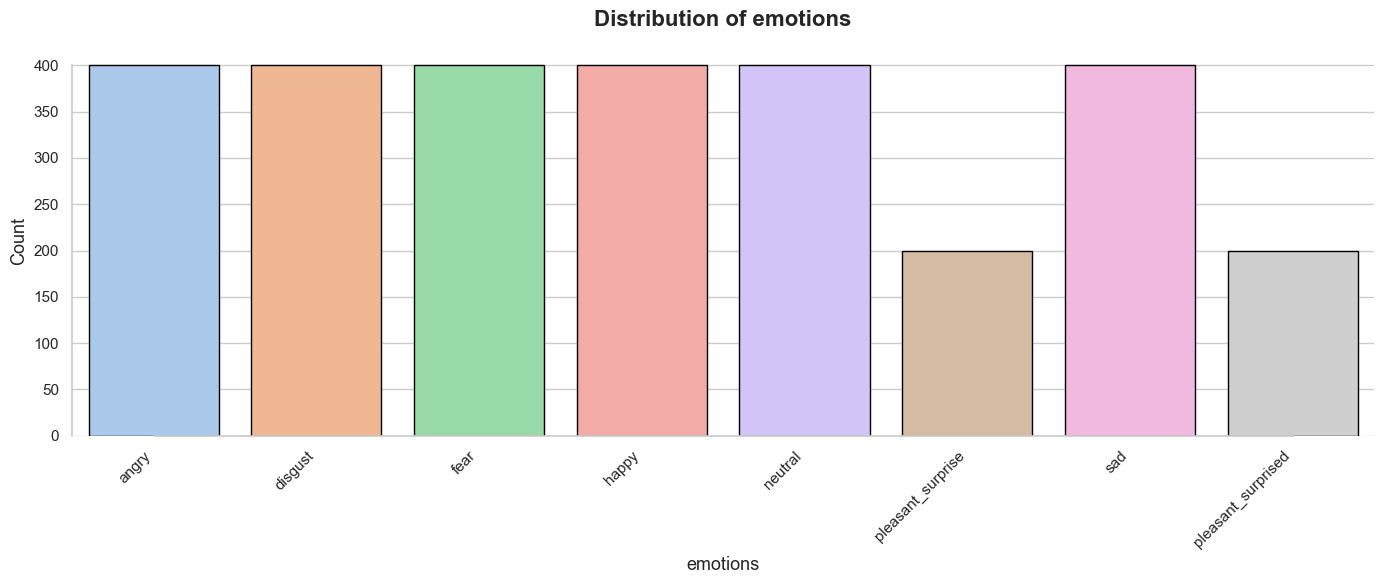

In [14]:
tess_data_cat = tess_data[['emotions']]

sns.set(style="whitegrid")
plt.rcParams.update({'axes.titlesize': 16, 'axes.titleweight': 'bold', 'axes.labelsize': 12})

num_features = len(tess_data_cat.columns)

for i, col in enumerate(tess_data_cat.columns, 1):
    plt.figure(figsize=(14, 6))
    
    palette = sns.color_palette("pastel", tess_data_cat[col].nunique())
    
    ax = sns.countplot(x=col, data=tess_data_cat, palette=palette, edgecolor='black')
    
    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(col, fontsize=13)
    plt.ylabel('Count', fontsize=13)
    
    if tess_data_cat[col].nunique() > 5:
        plt.xticks(rotation=45, ha='right', fontsize=11)
    else:
        plt.xticks(fontsize=11)
    
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

In [15]:
unique_emotions = tess_data['emotions'].unique()

for emotion in unique_emotions:
    emotion_files = tess_data[tess_data['emotions'] == emotion]['paths'].tolist()
    
    if len(emotion_files) < 2:
        continue  
    
    sample_file = emotion_files[1]
    
    display(Markdown(f"#### Emotion: {emotion.capitalize()}"))
    
    display(Audio(sample_file, autoplay=True))

#### Emotion: Angry

#### Emotion: Disgust

#### Emotion: Fear

#### Emotion: Happy

#### Emotion: Neutral

#### Emotion: Pleasant_surprise

#### Emotion: Sad

#### Emotion: Pleasant_surprised